In [ ]:
import hashlib, math, random
from functools import lru_cache
from typing import List, Tuple, Dict

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error

print("imports OK")

imports OK


In [ ]:
P = (1 << 64) - (1 << 32) + 1   # Goldilocks prime

def fadd(a, b): return (a + b) % P
def fmul(a, b): return (a * b) % P
def fpow(b, e): return pow(b, e, P)
def finv(a):    return pow(a, P - 2, P)

def get_omega(n):
    assert (P - 1) % n == 0
    o = fpow(7, (P - 1) // n)
    assert fpow(o, n) == 1 and fpow(o, n // 2) != 1
    return o

def build_domain(n, offset=1):
    o = get_omega(n)
    return [fmul(offset, fpow(o, i)) for i in range(n)]

def poly_eval(coeffs, x):
    r = 0
    for c in reversed(coeffs):
        r = fadd(fmul(r, x), c)
    return r

def poly_eval_domain(coeffs, domain):
    return [poly_eval(coeffs, x) for x in domain]

def fri_fold_by_2(evals, domain, beta):
    n = len(evals); half = n // 2
    ne, nd = [], []
    for i in range(half):
        x   = domain[i]
        fx  = evals[i]; fnx = evals[i + half]
        fe  = fmul(fadd(fx, fnx), finv(2))
        fo  = fmul((fx - fnx) % P, finv(fmul(2, x)))
        ne.append(fadd(fe, fmul(beta, fo)))
        nd.append(fmul(x, x))
    return ne, nd

print(f"P = {P}")

P = 18446744069414584321


In [ ]:
def collapse_rounds(coeffs, domain) -> int:
    evals  = poly_eval_domain(coeffs, domain)
    dom    = list(domain)
    rounds = 0
    while len(set(evals)) > 1:
        beta = random.randrange(2, P)
        evals, dom = fri_fold_by_2(evals, dom, beta)
        rounds += 1
        if len(evals) == 1:
            break
    return rounds

def true_degree(coeffs) -> int:
    d = 0
    for i, c in enumerate(coeffs):
        if c % P != 0:
            d = i
    return d

In [ ]:
_dom = build_domain(256, 7)
print("d_true -> empirical collapse rounds vs formula")
for d_true in [0, 1, 2, 3, 5, 7, 8, 15, 16, 31, 63, 100, 127]:
    coeffs = [0] * 256
    for i in range(d_true + 1):
        coeffs[i] = random.randrange(1, P)
    if d_true >= 0:
        coeffs[d_true] = random.randrange(1, P)
    emp = collapse_rounds(coeffs, _dom)
    formula = 0 if d_true == 0 else int(math.floor(math.log2(d_true))) + 1
    flag = "" if emp == formula else "  <-- MISMATCH"
    print(f"  d={d_true:4d}: empirical={emp}  formula={formula}{flag}")

d_true -> empirical collapse rounds vs formula
  d=   0: empirical=0  formula=0
  d=   1: empirical=1  formula=1
  d=   2: empirical=2  formula=2
  d=   3: empirical=2  formula=2
  d=   5: empirical=3  formula=3
  d=   7: empirical=3  formula=3
  d=   8: empirical=4  formula=4
  d=  15: empirical=4  formula=4
  d=  16: empirical=5  formula=5
  d=  31: empirical=5  formula=5
  d=  63: empirical=6  formula=6
  d= 100: empirical=7  formula=7
  d= 127: empirical=7  formula=7


In [ ]:
def round_cost(m: int, factor: int) -> int:
    depth = int(math.log2(m))
    return (m - 1) + factor * depth

def optimal_schedule(n0: int, R: int) -> Tuple[int, Tuple[int, ...]]:
    @lru_cache(maxsize=None)
    def solve(h: int):
        if h >= R:
            return 0, ()
        m = n0 >> h
        c2, s2 = solve(h + 1)
        best = (round_cost(m, 2) + c2, (2,) + s2)
        if m >= 4:
            c4, s4 = solve(h + 2)
            cand = (round_cost(m, 4) + c4, (4,) + s4)
            if cand[0] < best[0]:
                best = cand
        return best
    cost, sched = solve(0)
    solve.cache_clear()
    return cost, sched

def fixed_schedule_cost(n0: int, R: int, factor: int) -> Tuple[int, int]:
    h, cost, rounds = 0, 0, 0
    while h < R:
        m = n0 >> h
        f = factor
        if f == 4 and m < 4:
            f = 2
        cost += round_cost(m, f)
        h += (1 if f == 2 else 2)
        rounds += 1
    return cost, rounds

# demo
for R in [1, 2, 3, 5, 7]:
    c, s = optimal_schedule(512, R)
    print(f"R={R}: optimal cost={c}, schedule={s}")

R=1: optimal cost=529, schedule=(2,)
R=2: optimal cost=547, schedule=(4,)
R=3: optimal cost=688, schedule=(4, 2)
R=5: optimal cost=743, schedule=(4, 4, 2)
R=7: optimal cost=766, schedule=(4, 4, 4, 2)


In [ ]:
COEFF_SLOTS = 256          # max polynomial length
DOMAIN_SIZE = 512          # evaluation domain (blowup >= 2 over max degree)
DOMAIN      = build_domain(DOMAIN_SIZE, offset=7)

def random_polynomial(rng: random.Random) -> List[int]:
    style = rng.choice(["dense", "sparse", "low", "single", "clustered", "full"])
    coeffs = [0] * COEFF_SLOTS
    d = COEFF_SLOTS - 1 if style == "full" else rng.randint(1, COEFF_SLOTS - 1)

    if style in ("dense", "full"):
        for i in range(d + 1):
            coeffs[i] = rng.randrange(1, P)
    elif style == "low":
        d = rng.randint(1, 31)
        for i in range(d + 1):
            coeffs[i] = rng.randrange(1, P)
    elif style == "sparse":
        k = rng.randint(2, max(2, d // 4))
        idxs = rng.sample(range(d), k - 1) + [d]
        for i in idxs:
            coeffs[i] = rng.randrange(1, P)
    elif style == "single":
        coeffs[d] = rng.randrange(1, P)
    elif style == "clustered":
        lo = max(0, d - rng.randint(2, 8))
        for i in range(lo, d + 1):
            coeffs[i] = rng.randrange(1, P)

    coeffs[d] = rng.randrange(1, P)
    return coeffs

def coeff_features(coeffs: List[int]) -> np.ndarray:
    n = len(coeffs)
    nz = np.array([1.0 if (c % P) != 0 else 0.0 for c in coeffs])
    octaves, k = [], 0
    while (1 << k) < n:
        lo, hi = (1 << k), min(n, 1 << (k + 1))
        seg = nz[lo:hi]
        octaves.append(seg.mean() if len(seg) else 0.0)
        k += 1
    feats = [
        nz.sum() / n, nz.sum(), float(np.argmax(nz[::-1])),
        nz[: n // 2].mean(), nz[n // 2:].mean(),
        nz[: n // 4].mean(), nz[3 * n // 4:].mean(),
    ]
    feats.extend(octaves)
    return np.array(feats, dtype=np.float32)

def build_dataset(n_samples: int, seed: int = 0) -> Dict:
    rng = random.Random(seed)
    X, R_lab, cost_lab, degrees = [], [], [], []
    for _ in range(n_samples):
        coeffs = random_polynomial(rng)
        d = true_degree(coeffs)
        R = 0 if d == 0 else int(math.floor(math.log2(d))) + 1
        opt_cost, _ = optimal_schedule(DOMAIN_SIZE, R)
        X.append(coeff_features(coeffs))
        R_lab.append(R); cost_lab.append(opt_cost); degrees.append(d)
    return {"X": np.array(X), "R": np.array(R_lab),
            "cost": np.array(cost_lab, dtype=np.float32),
            "degree": np.array(degrees)}

data = build_dataset(4000, seed=0)
print(f"dataset: {len(data['X'])} polynomials | "
      f"degree [{data['degree'].min()}, {data['degree'].max()}] | "
      f"R [{data['R'].min()}, {data['R'].max()}] | "
      f"features/sample = {data['X'].shape[1]}")

dataset: 4000 polynomials | degree [1, 255] | R [1, 8] | features/sample = 15


In [ ]:
X, R, cost = data["X"], data["R"], data["cost"]
Xtr, Xte, Rtr, Rte, Ctr, Cte = train_test_split(
    X, R, cost, test_size=0.25, random_state=0)

clf = GradientBoostingClassifier(random_state=0).fit(Xtr, Rtr)
R_pred = clf.predict(Xte)
acc     = accuracy_score(Rte, R_pred)
within1 = np.mean(np.abs(R_pred - Rte) <= 1)

mlp = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=600,
                    random_state=0).fit(Xtr, Rtr)
acc_mlp = accuracy_score(Rte, mlp.predict(Xte))

reg = GradientBoostingRegressor(random_state=0).fit(Xtr, Ctr)
C_pred = reg.predict(Xte)
r2  = r2_score(Cte, C_pred)
mae = mean_absolute_error(Cte, C_pred)

print("--- held-out test set ---")
print(f"Collapse-depth R   | GBM acc = {acc:.3f} | within-1 = {within1:.3f}")
print(f"Collapse-depth R   | MLP acc = {acc_mlp:.3f}")
print(f"Optimal proof cost | GBM R^2 = {r2:.3f} | MAE = {mae:.1f} hash-units")

--- held-out test set ---
Collapse-depth R   | GBM acc = 1.000 | within-1 = 1.000
Collapse-depth R   | MLP acc = 0.954
Optimal proof cost | GBM R^2 = 1.000 | MAE = 0.0 hash-units


In [ ]:
print(f"{'d_true':>7} {'R':>3} {'all-x2':>9} {'all-x4':>9} {'optimal':>9} "
      f"{'best':>6} {'x4 vs x2':>9}")
rows = []
for d in [1, 3, 7, 15, 31, 63, 127, 255, 511]:
    if d >= DOMAIN_SIZE:
        continue
    Rd = int(math.floor(math.log2(d))) + 1
    c2, _ = fixed_schedule_cost(DOMAIN_SIZE, Rd, 2)
    c4, _ = fixed_schedule_cost(DOMAIN_SIZE, Rd, 4)
    copt, sopt = optimal_schedule(DOMAIN_SIZE, Rd)
    best = "x2" if c2 < c4 else ("x4" if c4 < c2 else "tie")
    delta = (c4 - c2) / c2 * 100
    rows.append((d, Rd, c2, c4, copt))
    print(f"{d:7d} {Rd:3d} {c2:9d} {c4:9d} {copt:9d} {best:>6} {delta:8.1f}%")

 d_true   R    all-x2    all-x4   optimal   best  x4 vs x2
      1   1       529       547       529     x2      3.4%
      3   2       800       547       547     x4    -31.6%
      7   3       941       702       688     x4    -25.4%
     15   4      1016       702       702     x4    -30.9%
     31   5      1057       753       743     x4    -28.8%
     63   6      1080       753       753     x4    -30.3%
    127   7      1093       772       766     x4    -29.4%
    255   8      1100       772       772     x4    -29.8%
    511   9      1103       775       775     x4    -29.7%


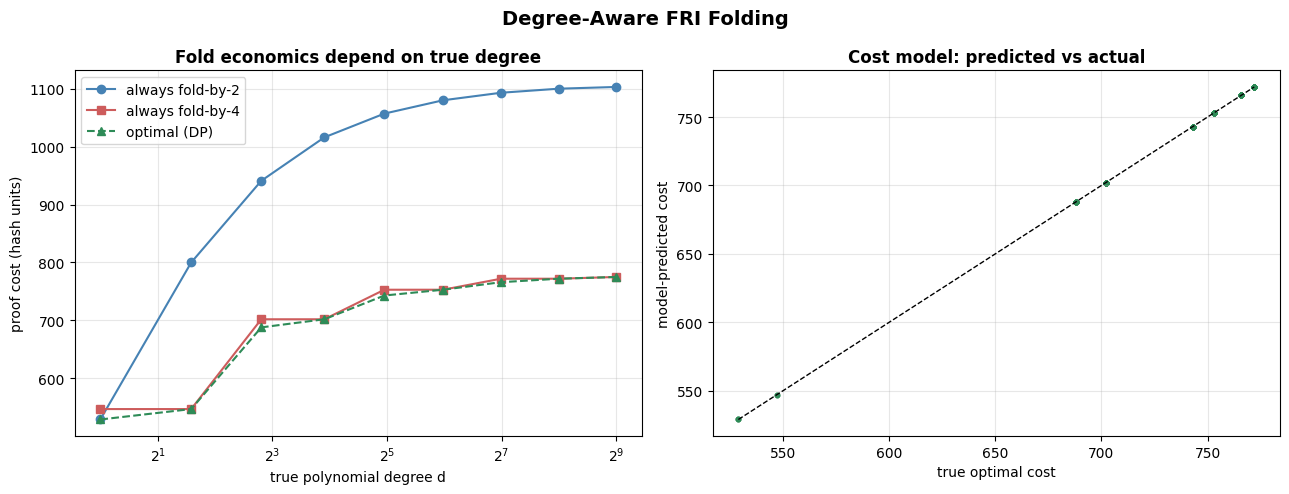

In [ ]:
degs = [r[0] for r in rows]
c2s  = [r[2] for r in rows]
c4s  = [r[3] for r in rows]
copts= [r[4] for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(degs, c2s, "o-", label="always fold-by-2", color="steelblue")
ax.plot(degs, c4s, "s-", label="always fold-by-4", color="indianred")
ax.plot(degs, copts, "^--", label="optimal (DP)", color="seagreen")
ax.set_xscale("log", base=2)
ax.set_xlabel("true polynomial degree d")
ax.set_ylabel("proof cost (hash units)")
ax.set_title("Fold economics depend on true degree", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
test = build_dataset(800, seed=999)
pred = reg.predict(test["X"])
ax.scatter(test["cost"], pred, s=10, alpha=0.4, color="seagreen")
lo, hi = test["cost"].min(), test["cost"].max()
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlabel("true optimal cost"); ax.set_ylabel("model-predicted cost")
ax.set_title("Cost model: predicted vs actual", fontweight="bold")
ax.grid(alpha=0.3)

fig.suptitle("Degree-Aware FRI Folding", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()